In [5]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy
import pandas as pd
#!pip install seaborn
import seaborn as sns
%matplotlib inline


In [15]:
import sys, os

# --------------------------------------------------
# 1. File paths
# --------------------------------------------------
#BASE_DIR = Path(__file__).resolve().parent.parent
BASE_DIR = Path.cwd().parent

In [16]:
DATA_FILE = (
    BASE_DIR
    / "data"
    / "processed"
    / "telco_customer_churn_clean.csv"
)


In [17]:
OUTPUT_DIR = BASE_DIR / "data" / "eda"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [18]:
# --------------------------------------------------
# 2. Load data
# --------------------------------------------------

df = pd.read_csv(DATA_FILE)

print("=" * 60)
print("TELCO CUSTOMER CHURN - EXPLORATORY DATA ANALYSIS")
print("=" * 60)




TELCO CUSTOMER CHURN - EXPLORATORY DATA ANALYSIS


In [19]:
# --------------------------------------------------
# 3. Basic dataset information
# --------------------------------------------------

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nChurn_score:")
print(df["churn_score"])

print("\nData types:")
print(df.dtypes)




Dataset shape:
(7043, 33)

First 5 rows:
   customerid  count        country       state         city  zip_code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 lat_long   latitude   longitude  gender  ...        contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  paperless_billing       

In [20]:
# --------------------------------------------------
# 4. Statistical summary
# --------------------------------------------------

print("\nNumerical summary:")
print(df.describe())




Numerical summary:
        count      zip_code     latitude    longitude  tenure_months  \
count  7043.0   7043.000000  7043.000000  7043.000000    7043.000000   
mean      1.0  93521.964646    36.282441  -119.798880      32.371149   
std       0.0   1865.794555     2.455723     2.157889      24.559481   
min       1.0  90001.000000    32.555828  -124.301372       0.000000   
25%       1.0  92102.000000    34.030915  -121.815412       9.000000   
50%       1.0  93552.000000    36.391777  -119.730885      29.000000   
75%       1.0  95351.000000    38.224869  -118.043237      55.000000   
max       1.0  96161.000000    41.962127  -114.192901      72.000000   

       monthly_charges  total_charges  churn_value  churn_score         cltv  
count      7043.000000    7043.000000  7043.000000  7043.000000  7043.000000  
mean         64.761692    2281.916928     0.265370    58.699418  4400.295755  
std          30.090047    2265.270398     0.441561    21.525131  1183.057152  
min          18

In [22]:
# --------------------------------------------------
# 5. Churn distribution
# --------------------------------------------------

print("\nChurn distribution:")
print(df["churn_value"].value_counts())

print("\nChurn percentage:")
churn_percentage = (
    df["churn_value"]
    .value_counts(normalize=True)
    * 100
)

print(churn_percentage)



Churn distribution:
churn_value
0    5174
1    1869
Name: count, dtype: int64

Churn percentage:
churn_value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


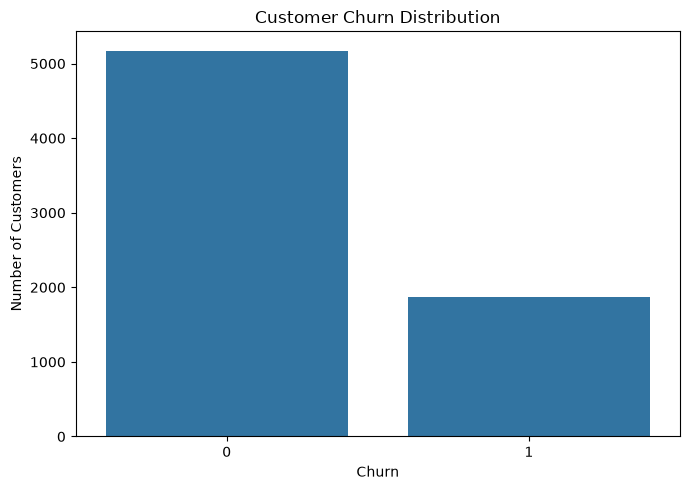

In [23]:
# --------------------------------------------------
# 6. Churn visualization
# --------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="churn_value"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "churn_distribution.png"
)

plt.show()



Churn percentage by contract:
churn_value             0          1
contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


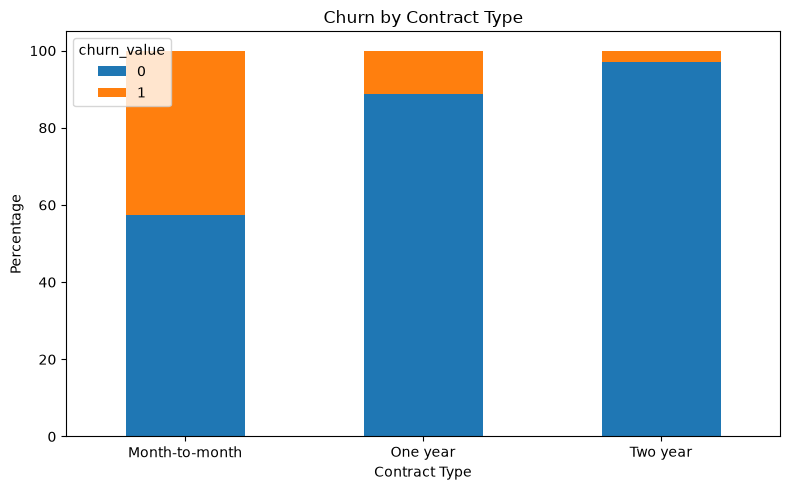

In [24]:
# --------------------------------------------------
# 7. Churn by contract
# --------------------------------------------------

if "contract" in df.columns:

    contract_churn = pd.crosstab(
        df["contract"],
        df["churn_value"],
        normalize="index"
    ) * 100

    print("\nChurn percentage by contract:")
    print(contract_churn)

    contract_churn.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5)
    )

    plt.title("Churn by Contract Type")
    plt.xlabel("Contract Type")
    plt.ylabel("Percentage")

    plt.xticks(rotation=0)

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "churn_by_contract.png"
    )

    plt.show()



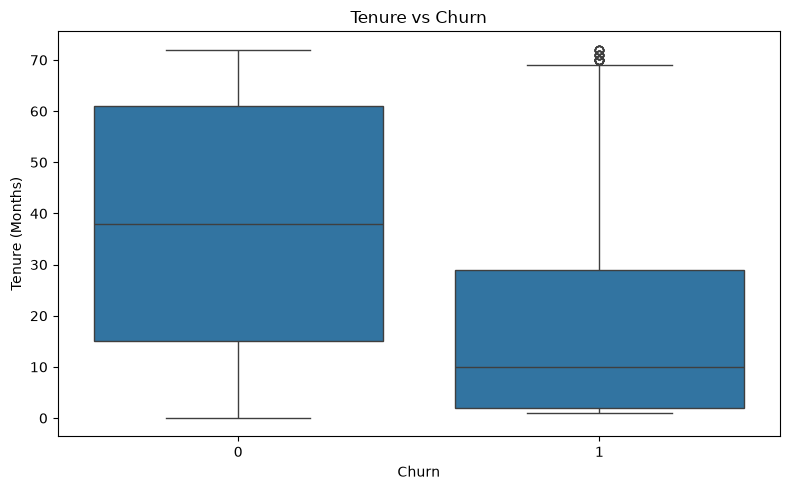

In [25]:
# --------------------------------------------------
# 8. Churn by tenure
# --------------------------------------------------

if "tenure_months" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="churn_value",
        y="tenure_months"
    )

    plt.title("Tenure vs Churn")
    plt.xlabel("Churn")
    plt.ylabel("Tenure (Months)")

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "tenure_vs_churn.png"
    )

    plt.show()